In [2]:
# ==========================================================
# 02_baseline_randomForest.py
# Baseline Random Forest + KNN Imputation + SHAP
# ==========================================================

import pandas as pd
import numpy as np
import os
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ----------------------------------------------------------
# 1. Load Clean Dataset
# ----------------------------------------------------------
file_path = "../dataset/clean_dengue_dataset.csv"
df = pd.read_csv(file_path)

# ----------------------------------------------------------
# 2. Separate Features and Target
# ----------------------------------------------------------
target_column = "dengue_label"

X = df.drop(columns=[target_column])
y = df[target_column]

feature_names = X.columns.tolist()

# ----------------------------------------------------------
# 3. Train-Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ----------------------------------------------------------
# 4. KNN Imputation
# ----------------------------------------------------------
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# ----------------------------------------------------------
# 5. Train Random Forest Model
# ----------------------------------------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_imputed, y_train)

# ----------------------------------------------------------
# 6. Predictions
# ----------------------------------------------------------
y_pred = model.predict(X_test_imputed)
y_prob = model.predict_proba(X_test_imputed)[:, 1]

# ----------------------------------------------------------
# 7. Evaluation Metrics
# ----------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("=" * 60)
print("BASELINE RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ----------------------------------------------------------
# 8. Create Output Folders
# ----------------------------------------------------------
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

/Users/anurag/miniconda3/envs/shap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BASELINE RANDOM FOREST RESULTS
Accuracy : 0.9293
F1 Score : 0.9466
ROC AUC  : 0.9027

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.87      0.90        69
           1       0.93      0.96      0.95       129

    accuracy                           0.93       198
   macro avg       0.93      0.92      0.92       198
weighted avg       0.93      0.93      0.93       198



In [3]:
# ----------------------------------------------------------
# 9. Save Metrics
# ----------------------------------------------------------
metrics_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "ROC_AUC": [roc]
})

metrics_df.to_csv(
    "outputs/baseline_randomForest_metrics.csv",
    index=False
)

# ----------------------------------------------------------
# 10. SHAP Explanation
# ----------------------------------------------------------
explainer = shap.TreeExplainer(model)

raw_shap_values = explainer.shap_values(X_test_imputed)

# Handle SHAP output formats safely
if isinstance(raw_shap_values, list):
    # Old SHAP format: list of arrays per class
    shap_values = raw_shap_values[1]
    base_value = explainer.expected_value[1]

elif len(np.array(raw_shap_values).shape) == 3:
    # New SHAP format: (samples, features, classes)
    shap_values = raw_shap_values[:, :, 1]
    base_value = explainer.expected_value[1]

else:
    # Already 2D
    shap_values = raw_shap_values
    base_value = explainer.expected_value

# ----------------------------------------------------------
# 11. Mean Absolute SHAP Importance
# ----------------------------------------------------------
importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nBaseline SHAP Feature Importance:\n")
print(importance_df)

importance_df.to_csv(
    "outputs/baseline_randomForest_shap_importance.csv",
    index=False
)



Baseline SHAP Feature Importance:

                       Feature  Importance
3                    wbc_count    0.201279
6               platelet_count    0.125220
7  platelet_distribution_width    0.032553
2              hemoglobin_g_dl    0.024726
0                          age    0.021115
1                       gender    0.010472
5                    rbc_count    0.005095
4           differential_count    0.003510


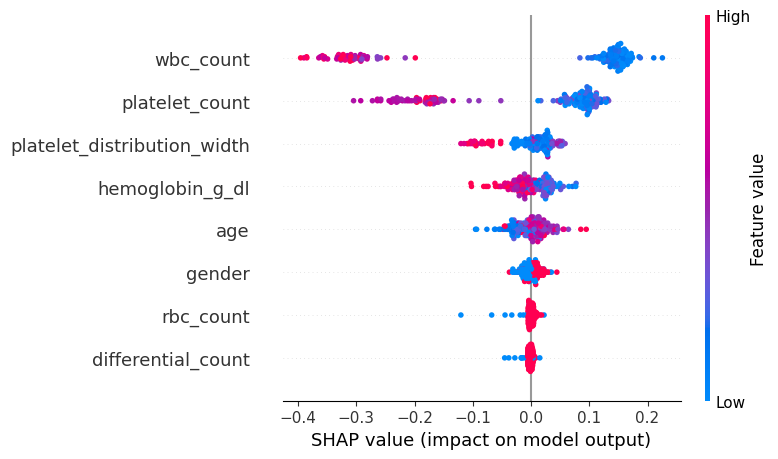

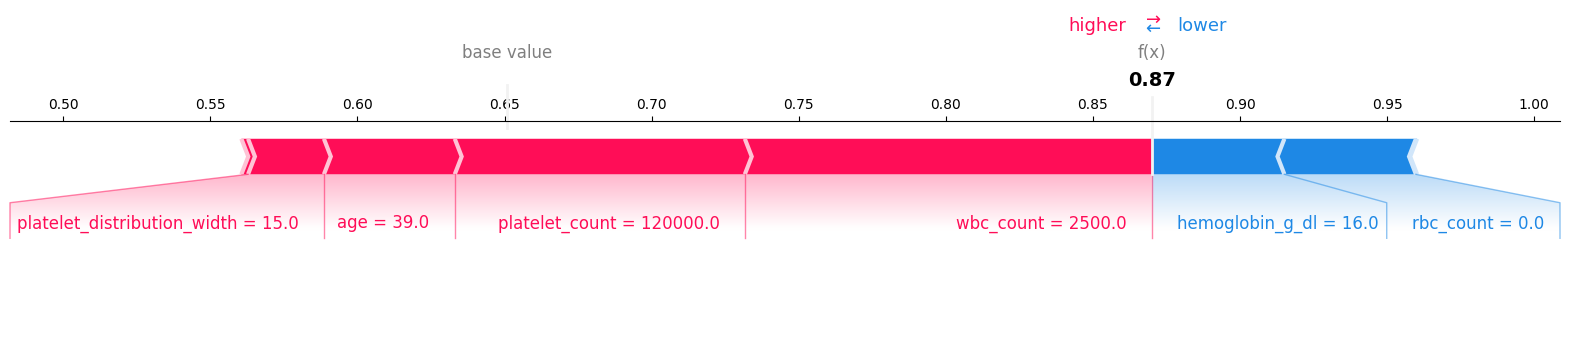


Files Saved Successfully:
- baseline_randomForest_metrics.csv
- baseline_randomForest_shap_importance.csv
- baseline_randomForest_summary_plot.png
- baseline_randomForest_force_plot.html

PROCESS COMPLETED SUCCESSFULLY


In [4]:
# ----------------------------------------------------------
# 12. SHAP Summary Plot
# ----------------------------------------------------------
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_imputed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

plt.savefig(
    "outputs/plots/baseline_randomForest_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ----------------------------------------------------------
# 13. SHAP Force Plot (Instance 0)
# ----------------------------------------------------------
shap.force_plot(
    base_value,
    shap_values[2],
    X_test_imputed[2],
    feature_names=feature_names,
    matplotlib=True
)

# shap.save_html(
#     "outputs/plots/baseline_randomForest_force_plot.html",
# )

# ----------------------------------------------------------
# 14. Completed
# ----------------------------------------------------------
print("\nFiles Saved Successfully:")
print("- baseline_randomForest_metrics.csv")
print("- baseline_randomForest_shap_importance.csv")
print("- baseline_randomForest_summary_plot.png")
print("- baseline_randomForest_force_plot.html")

print("\nPROCESS COMPLETED SUCCESSFULLY")